<a href="https://colab.research.google.com/github/kimjiwoo2/Pill-agent/blob/develop/notebooks/jiwoo/05_jw_cls_eda_manifest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **0. Overview**

### **탐색 및 초기 파이프라인**

- manifest 구조 확인, DB 조인, 속성 분포 EDA, 초기 학습 파이프라인 구성
- `pilliot_15k_v1_classification_manifest.csv` :single+combination, DB 조인 완료, 레이블 전처리 전 raw 상태
- 원본 이미지 드라이브 저장




# **1. Import**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import torch

!pip install pymysql
import pymysql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.0 MB/s eta 0:00:00


# **2. Manifest Load**

In [17]:
# Image ZIP
zip_path = '/content/drive/MyDrive/ToBigs/2425/Pillot/dataset/pilliot_15k_v1_final.zip'

# 내부 구조만 먼저 확인
with zipfile.ZipFile(zip_path, 'r') as z:
    names = z.namelist()
    print(f"총 파일 수: {len(names)}")
    print("\n상위 20개 경로:")
    for n in names[:20]:
        print(n)

총 파일 수: 15032

상위 20개 경로:
pilliot_15k_v1_final/
pilliot_15k_v1_final/images/
pilliot_15k_v1_final/images/combination/
pilliot_15k_v1_final/images/combination/TS_8_∞í░φò⌐/
pilliot_15k_v1_final/images/combination/TS_8_∞í░φò⌐/K-016235-019861-029667-030308_0_2_0_2_75_000_200.png
pilliot_15k_v1_final/images/combination/TS_8_∞í░φò⌐/K-015710-027653-030308-036637_0_2_0_2_90_000_200.png
pilliot_15k_v1_final/images/combination/TS_8_∞í░φò⌐/K-015710-027653-028763-036637_0_2_0_2_90_000_200.png
pilliot_15k_v1_final/images/combination/TS_8_∞í░φò⌐/K-016232-016235-020877-030308_0_2_0_2_70_000_200.png
pilliot_15k_v1_final/images/combination/TS_8_∞í░φò⌐/K-016232-033026-041768_0_2_0_2_75_000_200.png
pilliot_15k_v1_final/images/combination/TS_8_∞í░φò⌐/K-016235-016262-019861-030308_0_2_0_2_90_000_200.png
pilliot_15k_v1_final/images/combination/TS_8_∞í░φò⌐/K-016235-020238-027733-028763_0_2_0_2_75_000_200.png
pilliot_15k_v1_final/images/combination/TS_8_∞í░φò⌐/K-016235-016262-019861-034597_0_2_0_2_75_000_200.

In [18]:
# Manifest CSV ZIP
manifest_path = '/content/drive/MyDrive/ToBigs/2425/Pillot/dataset/pilliot_manifests.zip'

with zipfile.ZipFile(manifest_path, 'r') as z:
    print("내부 파일 목록:")
    for name in z.namelist():
        print(name)

내부 파일 목록:
classification_single_manifest_all.csv
classification_single_train.csv
classification_single_validation.csv
detection_combination.csv
detection_manifest_all.csv
detection_single.csv


In [19]:
with zipfile.ZipFile(manifest_path, 'r') as z:
    with z.open('classification_single_manifest_all.csv') as f:
        df = pd.read_csv(f, nrows=5)
        print(df.columns.tolist())
        print(df.head())

['dataset_type', 'split_type', 'label_zip_name', 'image_file', 'item_seq', 'dl_name', 'dl_company', 'dl_material', 'drug_dir', 'width', 'height']
  dataset_type split_type label_zip_name                       image_file  \
0       single      train   TL_35_단일.zip  K-011032_0_2_0_0_70_000_200.png   
1       single      train   TL_35_단일.zip  K-011032_0_2_0_0_70_020_200.png   
2       single      train   TL_35_단일.zip  K-011032_0_2_0_0_70_040_200.png   
3       single      train   TL_35_단일.zip  K-011032_0_2_0_0_70_060_200.png   
4       single      train   TL_35_단일.zip  K-011032_0_2_0_0_70_080_200.png   

   item_seq     dl_name dl_company dl_material drug_dir  width  height  
0         0  메소칸캡슐 50mg  초당약품공업(주)    메소글리칸나트륨       앞면    976    1280  
1         0  메소칸캡슐 50mg  초당약품공업(주)    메소글리칸나트륨       앞면    976    1280  
2         0  메소칸캡슐 50mg  초당약품공업(주)    메소글리칸나트륨       앞면    976    1280  
3         0  메소칸캡슐 50mg  초당약품공업(주)    메소글리칸나트륨       앞면    976    1280  
4         0  메소칸캡슐 50mg  초

In [20]:
with zipfile.ZipFile(manifest_path, 'r') as z:
    with z.open('detection_single.csv') as f:
        df = pd.read_csv(f, nrows=5)
        print(df.columns.tolist())
        print(df.head())

['dataset_type', 'split_type', 'label_zip_name', 'image_file', 'item_seq', 'dl_name', 'width', 'height', 'category_id', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h', 'area']
  dataset_type split_type label_zip_name                       image_file  \
0       single      train   TL_21_단일.zip  K-000027_0_2_0_0_75_000_200.png   
1       single      train   TL_21_단일.zip  K-000027_0_2_0_0_75_020_200.png   
2       single      train   TL_21_단일.zip  K-000027_0_2_0_0_75_040_200.png   
3       single      train   TL_21_단일.zip  K-000027_0_2_0_0_75_060_200.png   
4       single      train   TL_21_단일.zip  K-000027_0_2_0_0_75_080_200.png   

    item_seq        dl_name  width  height  category_id  bbox_x  bbox_y  \
0  195900043  아네모정 90mg/PTP    976    1280            1   294.0   475.0   
1  195900043  아네모정 90mg/PTP    976    1280            1   303.0   461.0   
2  195900043  아네모정 90mg/PTP    976    1280            1   313.0   452.0   
3  195900043  아네모정 90mg/PTP    976    1280            1   326.0   445

In [21]:
# Manifest에서 이미지 파일 필터링
manifest_path = '/content/drive/MyDrive/ToBigs/2425/Pillot/dataset/pilliot_manifests.zip'
dataset_path = '/content/drive/MyDrive/ToBigs/2425/Pillot/dataset/pilliot_15k_v1_final.zip'

zip12_single = [
    'TL_81_단일.zip', 'TL_76_단일.zip', 'TL_46_단일.zip', 'TL_38_단일.zip',
    'TL_48_단일.zip', 'TL_43_단일.zip', 'TL_70_단일.zip', 'TL_73_단일.zip',
    'TL_54_단일.zip', 'TL_41_단일.zip', 'TL_75_단일.zip', 'TL_57_단일.zip'
]

# 실제 이미지 파일명 → zip 내부 전체 경로 매핑
with zipfile.ZipFile(dataset_path, 'r') as z:
    path_map = {}
    actual_files = set()
    for name in z.namelist():
        if name.endswith('.png') or name.endswith('.jpg'):
            filename = name.split('/')[-1]
            path_map[filename] = name
            actual_files.add(filename)

print(f"실제 이미지 파일 수: {len(actual_files)}")

# single manifest 로드 및 필터링
with zipfile.ZipFile(manifest_path, 'r') as z:
    with z.open('detection_single.csv') as f:
        df_single = pd.read_csv(f)

df_single = df_single[df_single['label_zip_name'].isin(zip12_single)]
df_single = df_single[df_single['image_file'].isin(actual_files)]
print(f"single 매칭: {len(df_single)}행")

# combination manifest 로드 및 필터링
with zipfile.ZipFile(manifest_path, 'r') as z:
    with z.open('detection_combination.csv') as f:
        df_comb = pd.read_csv(f)

df_comb = df_comb[df_comb['image_file'].isin(actual_files)]
print(f"combination 매칭: {len(df_comb)}행")

# 합치기
df_cls_final = pd.concat([df_single, df_comb], ignore_index=True)

# zip 내부 전체 경로 컬럼 추가
df_cls_final['zip_path'] = df_cls_final['image_file'].map(path_map)

print(f"최종: {len(df_cls_final)}행")
print(f"매핑 실패: {df_cls_final['zip_path'].isna().sum()}행")
print(df_cls_final[['image_file', 'zip_path', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h']].head(3))

실제 이미지 파일 수: 15000
single 매칭: 12000행
combination 매칭: 11494행
최종: 23494행
매핑 실패: 0행
                        image_file  \
0  K-012685_0_0_0_0_75_280_200.png   
1  K-012685_0_0_0_1_75_240_200.png   
2  K-012685_0_0_1_0_75_340_200.png   

                                            zip_path  bbox_x  bbox_y  bbox_w  \
0  pilliot_15k_v1_final/images/single/TS_38_δï¿∞¥...   375.0   526.0   191.0   
1  pilliot_15k_v1_final/images/single/TS_38_δï¿∞¥...   374.0   531.0   188.0   
2  pilliot_15k_v1_final/images/single/TS_38_δï¿∞¥...   420.0   557.0   192.0   

   bbox_h  
0   187.0  
1   187.0  
2   186.0  


# **3. DB 조인**

In [22]:
# Manifest CSV에는 속성 분류를 위한 컬럼 존재하지 않음
print(df_cls_final.columns.tolist())

['dataset_type', 'split_type', 'label_zip_name', 'image_file', 'item_seq', 'dl_name', 'width', 'height', 'category_id', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h', 'area', 'zip_path']


In [23]:
conn = pymysql.connect(
    host='103.218.161.72',
    port=3306,
    user='jiwoo_admin',
    password='1234',
    database='pilliot_db',
    charset='utf8mb4'
)

item_seqs_str = ','.join(map(str, [int(x) for x in df_cls_final['item_seq'].dropna().unique()]))

query = f"""
SELECT item_seq, dl_mapping_code,
       drug_shape, color_class1, color_class2,
       form_code_name, line_front, line_back,
       print_front, print_back,
       chart, di_class_no, di_etc_otc_code, di_edi_code
FROM drug_master
WHERE item_seq IN ({item_seqs_str})
"""
df_drug = pd.read_sql(query, conn)

df_cls_final = df_cls_final.merge(df_drug, on='item_seq', how='left')
print(f"조인 결과: {len(df_cls_final)}행")
print(df_cls_final.columns.tolist())

# 저장: pilliot_15k_v1_classification_manifest.csv
# single + combination 전체 (23,494행), DB 조인 완료
# 레이블 전처리 전 raw 상태
df_cls_final.to_csv('/content/drive/MyDrive/ToBigs/2425/Pillot/dataset/pilliot_15k_v1_full_manifest_raw.csv', index=False)
print("저장 완료")

/tmp/ipykernel_730/2112361295.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_drug = pd.read_sql(query, conn)


조인 결과: 23494행
['dataset_type', 'split_type', 'label_zip_name', 'image_file', 'item_seq', 'dl_name', 'width', 'height', 'category_id', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h', 'area', 'zip_path', 'dl_mapping_code', 'drug_shape', 'color_class1', 'color_class2', 'form_code_name', 'line_front', 'line_back', 'print_front', 'print_back', 'chart', 'di_class_no', 'di_etc_otc_code', 'di_edi_code']
저장 완료


- **`item_seq` — 품목 고유 식별자 (Primary Key). 식약처 품목 코드.**

- **`dl_mapping_code` — 식약처 의약품 매핑 코드. 외부 DB 연동 시 사용.**

- **`dl_name` — 약품 한글 이름. 예: 타이레놀정500mg.**

- `dl_name_en` — 약품 영문 이름.

- `dl_company` — 제조사/판매사 이름. 예: 한국얀센.

- `dl_material` — 주성분 한글명. 예: 아세트아미노펜.

- `dl_material_en` — 주성분 영문명. 예: Acetaminophen.

- **`drug_shape` — 알약 모양. 원형/타원형/장방형 등.**

- **`color_class1` — 주색상.**

- **`color_class2` — 부색상. 투톤일 때만 값 있음.**

- **`form_code_name` — 제형. 정제/캡슐/연질캡슐 등.**

- `print_front` — 앞면 각인 텍스트. OCR 정답 레이블로 활용 가능.

- `print_back` — 뒷면 각인 텍스트.  OCR 정답 레이블로 활용 가능.

- `line_front` — 앞면 분할선 유무/형태.

- `line_back` — 뒷면 분할선 유무/형태.

- `chart` — 약품 외형 설명 텍스트. 색상/모양/크기 등 자연어로 기술된 정보.

- `di_class_no` — 약효 분류 번호. 어떤 질환에 쓰이는 약인지 분류.

- `di_etc_otc_code` — 전문의약품/일반의약품 구분 코드.

- `di_edi_code` — 건강보험 EDI 코드. DUR 데이터 연동 시 핵심 키값.

# **4. EDA**
- single vs combination 분포 비교
- 각 속성 (drug_shape, color_class1, form_code_name, line_front) 분포 확인
- bbox 크기 분포
- 품목 수 확인

In [24]:
# combination vs single 분포 비교
df_single_only = df_cls_final[df_cls_final['dataset_type'] == 'single']
df_comb_only = df_cls_final[df_cls_final['dataset_type'] == 'combination']

print(f"single: {len(df_single_only)}행 / combination: {len(df_comb_only)}행")

for col in ['drug_shape', 'color_class1', 'form_code_name', 'line_front']:
    print(f"\n[{col}]")
    print(pd.DataFrame({
        'single': df_single_only[col].value_counts(normalize=True).round(3),
        'combination': df_comb_only[col].value_counts(normalize=True).round(3)
    }).fillna(0))

single: 12000행 / combination: 11494행

[drug_shape]
            single  combination
drug_shape                     
기타           0.073        0.009
사각형          0.006        0.000
삼각형          0.005        0.009
오각형          0.006        0.000
원형           0.292        0.351
육각형          0.004        0.012
장방형          0.292        0.314
타원형          0.250        0.295
팔각형          0.073        0.010

[color_class1]
              single  combination
color_class1                     
갈색             0.076        0.063
갈색, 투명         0.010        0.000
검정             0.011        0.000
노랑             0.133        0.153
노랑, 투명         0.012        0.003
보라             0.022        0.000
분홍             0.108        0.137
분홍, 투명         0.004        0.000
빨강             0.007        0.027
빨강, 투명         0.007        0.000
연두             0.075        0.020
자주             0.008        0.000
주황             0.084        0.071
주황, 투명         0.003        0.000
청록             0.016        0.000
청록,

In [25]:
# 각 속성 고유값 및 분포 확인
for col in ['drug_shape', 'color_class1', 'form_code_name', 'line_front']:
    print(f"\n[{col}] 고유값 수: {df_cls_final[col].nunique()}")
    print(df_cls_final[col].value_counts(dropna=False))


[drug_shape] 고유값 수: 9
drug_shape
원형      7444
장방형     7032
타원형     6312
팔각형      996
기타       983
None     258
육각형      180
삼각형      154
사각형       69
오각형       66
Name: count, dtype: int64

[color_class1] 고유값 수: 24
color_class1
하양        8001
노랑        3316
분홍        2837
주황        1799
갈색        1611
초록        1481
연두        1130
파랑        1050
빨강         392
보라         260
None       258
청록         186
노랑, 투명     177
파랑, 투명     140
초록, 투명     133
검정         127
갈색, 투명     120
회색         115
자주          99
빨강, 투명      79
분홍, 투명      50
투명          41
주황, 투명      37
청록, 투명      36
하양, 노랑      19
Name: count, dtype: int64

[form_code_name] 고유값 수: 16
form_code_name
필름코팅정         11460
나정             4424
경질캡슐제, 산제      3382
연질캡슐제, 액상      1062
서방성필름코팅정        950
장용성필름코팅정        653
연질캡슐제, 현탁상      375
서방성캡슐제, 펠렛      308
None            258
다층정             155
추어블정(저작정)       149
구강붕해정           137
경질캡슐제, 과립제       82
당의정              66
산제               23
발포정               6
서방정    

-> combination으로부터 파생된 이미지로 인해 single 기준 EDA 분포가 깨짐.

-> 우선 첫 번째 단계에서는 single 이미지만을 활용하여 분류기 학습하기로 결정

In [26]:
single_items = set(df_cls_final[df_cls_final['dataset_type'] == 'single']['item_seq'].unique())
comb_items = set(df_cls_final[df_cls_final['dataset_type'] == 'combination']['item_seq'].unique())

print(f"manifest 전체 행 수: {len(df_cls_final)}")
print(f"고유 item_seq 수: {df_cls_final['item_seq'].nunique()}")
print(f"single 품목 수: {len(single_items)}")
print(f"combination 품목 수: {len(comb_items)}")
print(f"combination에만 있는 품목 수: {len(comb_items - single_items)}")

manifest 전체 행 수: 23494
고유 item_seq 수: 678
single 품목 수: 569
combination 품목 수: 118
combination에만 있는 품목 수: 109


In [27]:
# bbox 크기 분포
df_single['bbox_area'] = df_single['bbox_w'] * df_single['bbox_h']

print(df_single[['bbox_w', 'bbox_h', 'bbox_area']].describe())

# 너무 작은 bbox 확인
small_bbox = df_single[df_single['bbox_area'] < 50*50]
print(f"\nbbox 50x50 미만: {len(small_bbox)}행")

             bbox_w        bbox_h      bbox_area
count  12000.000000  12000.000000   12000.000000
mean     272.261500    266.549917   77206.346917
std      105.614493    101.203292   50541.043086
min      112.000000    123.000000   19317.000000
25%      189.000000    188.000000   38058.750000
50%      234.000000    231.000000   59628.000000
75%      332.000000    323.000000  105723.750000
max      685.000000    699.000000  417780.000000

bbox 50x50 미만: 0행


In [ ]:
# color_class1 속성 - 복합값 알약 샘플 확인
complex_colors = df_single[df_single['color_class1'].str.contains(',', na=False)]
print(f"복합값 총 행 수: {len(complex_colors)}")
print(f"고유 품목 수: {complex_colors['item_seq'].nunique()}")
print("\n샘플:")
print(complex_colors[['item_seq', 'dl_name', 'color_class1', 'drug_shape', 'form_code_name']].drop_duplicates('item_seq').head(10))

복합값 총 행 수: 738
고유 품목 수: 17

샘플:
       item_seq              dl_name color_class1 drug_shape form_code_name
2566  200403625   푸푸에프연질캡슐 100mg/PTP       빨강, 투명        장방형      연질캡슐제, 액상
2615  200403642   두캅스에이연질캡슐 75mg/PTP       초록, 투명        타원형      연질캡슐제, 액상
2683  200403671   에이스펜연질캡슐 250mg/PTP       주황, 투명        장방형      연질캡슐제, 액상
3529  200501556              리브롤연질캡슐       갈색, 투명        장방형      연질캡슐제, 액상
3652  200501601              레가셀연질캡슐       갈색, 투명        장방형      연질캡슐제, 액상
3841  200501939              레가탄연질캡슐       갈색, 투명        타원형      연질캡슐제, 액상
6943  200902364  이프렌에스연질캡슐 300mg/PTP       청록, 투명        장방형      연질캡슐제, 액상
7107  200902769     그린노즈에스캡슐 3mg/PTP       초록, 투명        장방형     서방성캡슐제, 펠렛
7489  201310950    이지펜연질캡슐 300mg/PTP       빨강, 투명        타원형      연질캡슐제, 액상
7704  201400293  캐치콜에스연질캡슐 200mg/PTP       노랑, 투명        타원형      연질캡슐제, 액상


/tmp/ipykernel_1476/720075702.py:23: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1476/720075702.py:23: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1476/720075702.py:23: UserWarning: Glyph 53804 (\N{HANGUL SYLLABLE TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1476/720075702.py:23: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1476/720075702.py:23: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1476/720075702.py:23: UserWarning: Glyph 47536 (\N{HANGUL SYLLABLE RIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1476/720075702.py:23: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

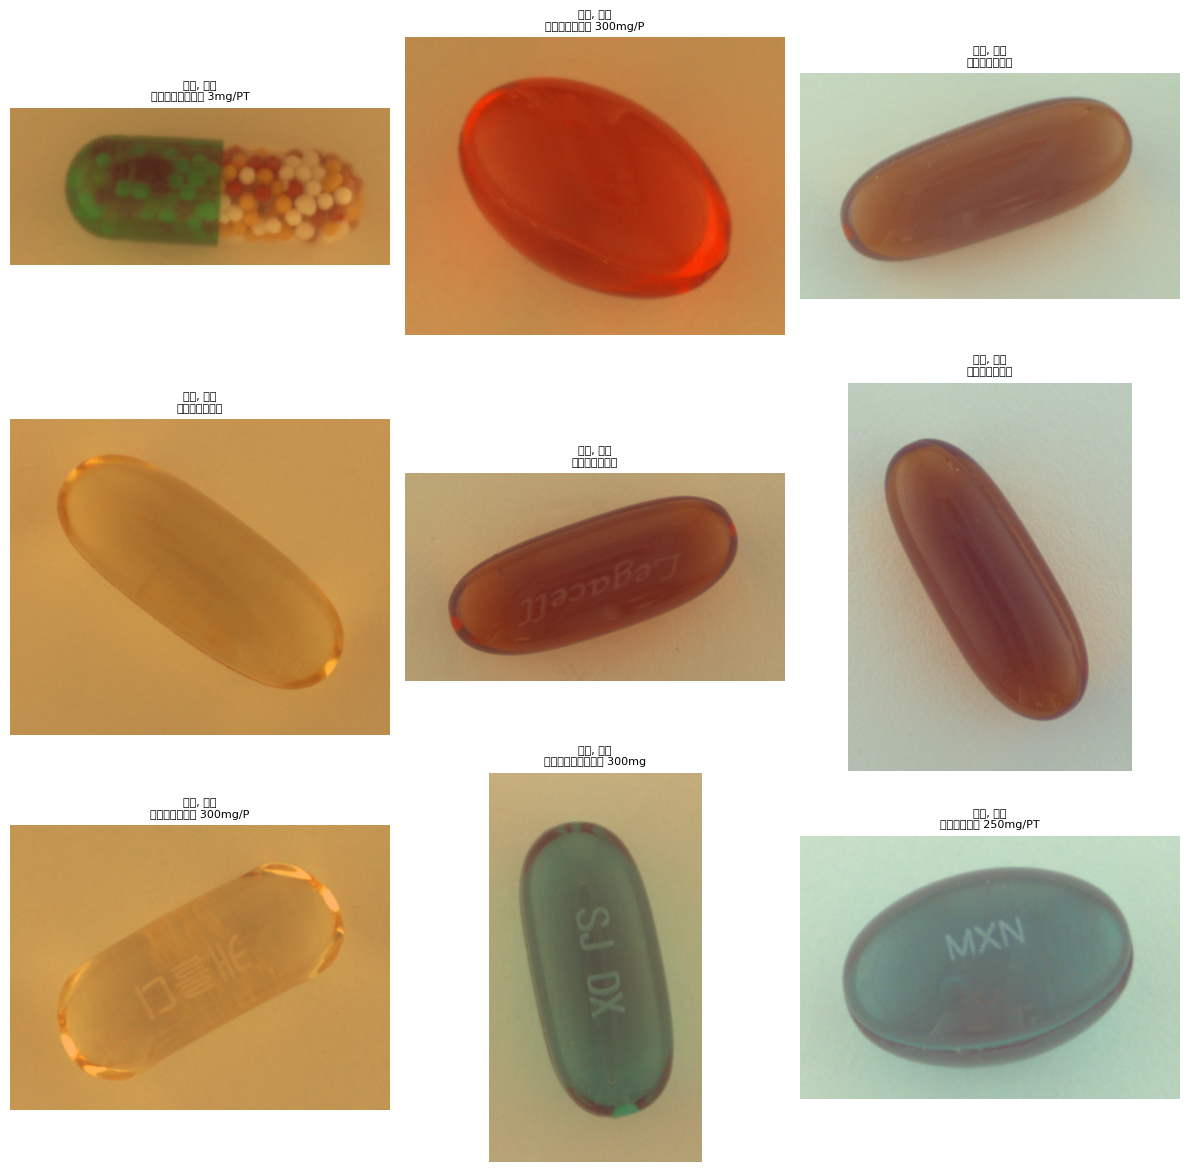

In [ ]:
# 투명 계열 알약 이미지 샘플 시각화
complex_colors = df_single[df_single['color_class1'].str.contains(',', na=False)]
samples = complex_colors.sample(9, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
with zipfile.ZipFile(dataset_path, 'r') as z:
    for ax, (_, row) in zip(axes.flatten(), samples.iterrows()):
        with z.open(row['zip_path']) as f:
            img = Image.open(f)
            img.load()
        x, y, w, h = int(row['bbox_x']), int(row['bbox_y']), int(row['bbox_w']), int(row['bbox_h'])
        pad_x, pad_y = int(w * 0.1), int(h * 0.1)
        img_w, img_h = img.size
        x1 = max(0, x - pad_x)
        y1 = max(0, y - pad_y)
        x2 = min(img_w, x + w + pad_x)
        y2 = min(img_h, y + h + pad_y)
        cropped = img.crop((x1, y1, x2, y2))
        ax.imshow(cropped)
        ax.set_title(f"{row['color_class1']}\n{row['dl_name'][:15]}", fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.show()

# **5. 원본 이미지 압축 해제 및 저장**

In [ ]:
# 압축 해제
extract_path = '/content/drive/MyDrive/ToBigs/2425/Pillot/dataset/pilliot_15k_v1_final/'

if not os.path.exists(extract_path):
    print("압축 해제 중...")
    with zipfile.ZipFile(dataset_path, 'r') as z:
        z.extractall(extract_path)
    print("완료")
else:
    print("이미 압축 해제됨")

압축 해제 중...
완료
